In [ ]:
from dinov2.data.datasets.s2_csv import S2CsvDataset
from torchvision import transforms
from torch.utils.data import DataLoader

# 先算一次均值方差（可选）
# from dinov2.utils.data import compute_dataset_stats
# tmp_ds = S2CsvDataset(csv_path="data_csv/96_3_train.csv", scale_to_unit=True, pad_to_multiple=14, normalize_stats=None)
# compute_dataset_stats(tmp_ds, subset=0.1)  # 输出 mean/std，填到 normalize_stats

train_tf = transforms.Compose([
    # 这里可以插入你需要的随机裁剪/翻转
])

ds_train = S2CsvDataset(
    csv_path="data_csv/96_3_train.csv",
    ds_cfg_name="s2_12band",
    normalize_stats=None,   # 如果已有 mean/std，填为 (mean, std)
    scale_to_unit=True,     # uint16 -> [0,1]
    pad_to_multiple=14,     # 96 -> 98，避免 patch 截断
    transform=train_tf,
)

ds_test = S2CsvDataset(
    csv_path="data_csv/96_3_test.csv",
    ds_cfg_name="s2_12band",
    normalize_stats=None,
    scale_to_unit=True,
    pad_to_multiple=14,
    transform=None,
)

train_loader = DataLoader(ds_train, batch_size=64, shuffle=True, num_workers=8)
test_loader = DataLoader(ds_test, batch_size=64, shuffle=False, num_workers=8)


In [9]:
from dinov2.data.datasets.s2_csv import S2CsvDataset

csv = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/s2_90360_temporal_CDSE0_gee90360_2024_16/train.csv"
subset = 1000  # 2% 抽样，可改为 int 比如 500
ds = S2CsvDataset(
    csv_path=csv,
    ds_cfg_name="s2_12band",
    scale_to_unit=False,
    compute_stats=True,
    compute_stats_subset=subset,
    pad_to_multiple=None,  # 统计时不需要 padding
)

mean, std = ds.get_normalize_stats()
print("mean =", mean.tolist())
print("std  =", std.tolist())

csv = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/s2_90360_temporal_CDSE0_gee90360_2024_16/test.csv"
subset = 1000  # 2% 抽样，可改为 int 比如 500
ds = S2CsvDataset(
    csv_path=csv,
    ds_cfg_name="s2_12band",
    scale_to_unit=False,
    compute_stats=True,
    compute_stats_subset=subset,
    pad_to_multiple=None,  # 统计时不需要 padding
)

mean, std = ds.get_normalize_stats()
print("mean =", mean.tolist())
print("std  =", std.tolist())


mean = [1834.1697998046875, 1997.9698486328125, 2386.554443359375, 2793.37060546875, 3182.25830078125, 3513.309814453125, 3685.052001953125, 3930.157958984375, 0.0, 0.0, 4635.279296875, 3836.010009765625]
std  = [328.0159912109375, 454.60638427734375, 554.505615234375, 723.8554077148438, 740.930419921875, 683.3168334960938, 673.1165771484375, 652.6875, 9.999999974752427e-07, 9.999999974752427e-07, 679.613525390625, 731.38232421875]
mean = [2201.8984375, 2484.21337890625, 2947.541748046875, 3823.814208984375, 4148.443359375, 4329.40576171875, 4488.68310546875, 4666.5751953125, 0.0, 0.0, 5810.994140625, 5510.0078125]
std  = [484.7310485839844, 645.2403564453125, 760.5748901367188, 910.9255981445312, 951.3125, 925.4602661132812, 925.116943359375, 906.8043212890625, 9.999999974752427e-07, 9.999999974752427e-07, 681.802978515625, 640.1221923828125]


In [10]:
import pandas as pd
import tempfile
from pathlib import Path

from dinov2.data.datasets.s2_csv import S2CsvDataset

# ======================
# Config
# ======================
TRAIN_CSV = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/s2_90360_temporal_CDSE0_gee90360_2024_16/train.csv"
TEST_CSV  = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/s2_90360_temporal_CDSE0_gee90360_2024_16/test.csv"

N_TRAIN = 1000
N_TEST  = 1000
RANDOM_SEED = 42

# ======================
# 1) Load & sample
# ======================
df_train = pd.read_csv(TRAIN_CSV)
df_test  = pd.read_csv(TEST_CSV)

df_train_sub = df_train.sample(n=N_TRAIN, random_state=RANDOM_SEED)
df_test_sub  = df_test.sample(n=N_TEST,  random_state=RANDOM_SEED)

df_mix = pd.concat([df_train_sub, df_test_sub], ignore_index=True)

print(f"[INFO] Mixed samples: train={len(df_train_sub)}, test={len(df_test_sub)}, total={len(df_mix)}")

# ======================
# 2) Write temp CSV
# ======================
tmp_dir = Path(tempfile.mkdtemp())
MIXED_CSV = tmp_dir / "train_test_mixed_2000.csv"
df_mix.to_csv(MIXED_CSV, index=False)

print(f"[INFO] Mixed CSV saved to: {MIXED_CSV}")

# ======================
# 3) Compute stats
# ======================
ds = S2CsvDataset(
    csv_path=str(MIXED_CSV),
    ds_cfg_name="s2_12band",
    scale_to_unit=False,
    compute_stats=True,
    compute_stats_subset=None,  # 已经是 2000，全用
    pad_to_multiple=None,
)

mean, std = ds.get_normalize_stats()

print("mean =", mean.tolist())
print("std  =", std.tolist())


[INFO] Mixed samples: train=1000, test=1000, total=2000
[INFO] Mixed CSV saved to: /tmp/tmphmho_tkd/train_test_mixed_2000.csv
mean = [2023.93408203125, 2267.178466796875, 2703.1396484375, 3257.457275390625, 3589.15478515625, 3874.7529296875, 4058.203125, 4229.97802734375, 0.0, 0.0, 4915.81591796875, 4429.00439453125]
std  = [659.8005981445312, 759.5709838867188, 878.8653564453125, 1164.0340576171875, 1186.4278564453125, 1077.7305908203125, 1084.9752197265625, 1064.8203125, 9.999999974752427e-07, 9.999999974752427e-07, 1363.797119140625, 1409.4805908203125]


In [6]:
import os
import pandas as pd
import tifffile
from collections import Counter

csv = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/plume_s2_-790360_32_2024/train_patches.csv"
df = pd.read_csv(csv)

cnt = Counter()
bad = []
for p in df["s2_pre_pre_path"].dropna().astype(str):
    if not os.path.exists(p):
        cnt["missing"] += 1
        continue
    try:
        arr = tifffile.imread(p)
        cnt[str(arr.shape)] += 1
        # 记录一下异常的
        if not (arr.ndim == 3 and arr.shape[0] == 12 and arr.shape[1] == 32 and arr.shape[2] == 32):
            bad.append((p, arr.shape))
    except Exception as e:
        cnt["read_fail"] += 1
        bad.append((p, f"FAIL:{e}"))

print("Shape counts:")
for k,v in cnt.most_common():
    print(v, k)

print("\nFirst 20 abnormal samples:")
for item in bad[:20]:
    print(item)


Shape counts:
4288 (12, 32, 32)

First 20 abnormal samples:


In [ ]:
import numpy as np
import tifffile

def plume_ratio(mask_path):
    m = tifffile.imread(mask_path)
    return (m > 0).mean()

# 分别算 train/test 的 label=1
mask_path="/home/yuyao/panopticon/data_csv/96_3_train.csv"
print(plume_ratio(mask_path))

In [6]:
import pandas as pd
from pathlib import Path

csv_path = Path("data_csv/hongxuan_temporal_32/test.csv")

df = pd.read_csv(csv_path)
df.to_csv(csv_path.with_suffix(".bak"), index=False)

df["plume_mask_path"] = df["plume_mask_path"].str.replace(
    r"^/home", "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao", regex=True
)

df.to_csv(csv_path, index=False)

In [1]:
from dinov2.data.datasets.landsat_csv import Landsat89CsvDataset

train_csv = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/emit_60m_to_224_classification_2025/train_permian.csv"
ds = Landsat89CsvDataset(
    csv_path=train_csv,
    ds_cfg_name="landsat89_7band",
    scale_to_unit=False,        # 若已是反射率则设 False
    compute_stats=True,
    compute_stats_subset=1000,  # 可选，加速
    pad_to_multiple=None,
    drop_extra_bands=True,     # 只保留 SR_B1..SR_B7
)
mean, std = ds.get_normalize_stats()
print("mean =", [float(m) for m in mean])
print("std  =", [float(s) for s in std])

mean = [0.12139824777841568, 0.14210745692253113, 0.1989395022392273, 0.2627725303173065, 0.356589138507843, 0.47721537947654724, 0.40299171209335327]
std  = [0.017132749781012535, 0.020369281992316246, 0.02752421796321869, 0.03416186571121216, 0.036992188543081284, 0.03588271513581276, 0.034712810069322586]


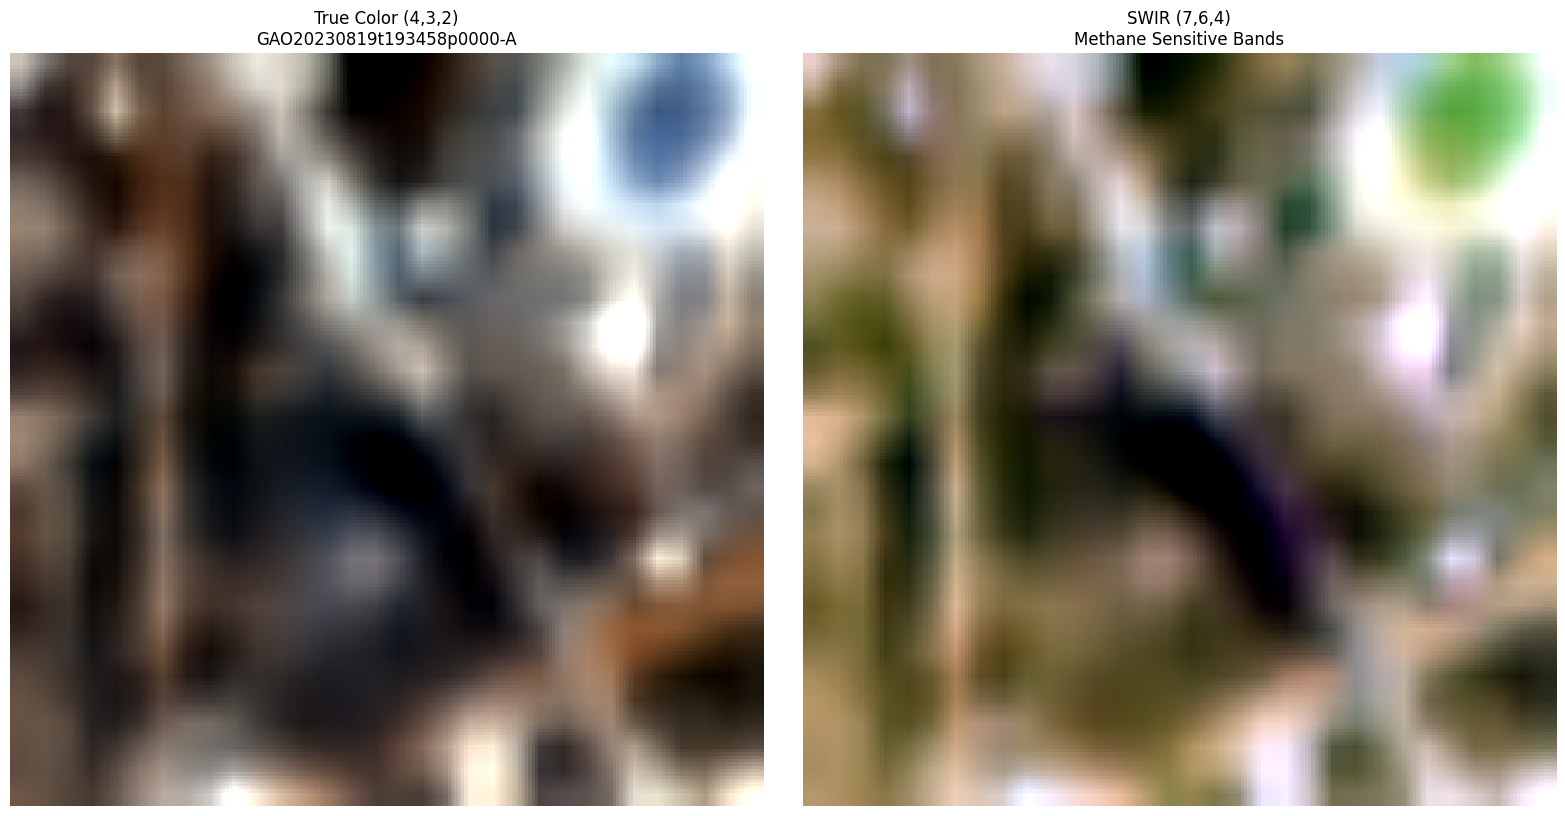

In [4]:
import pandas as pd
import numpy as np
import tifffile
import matplotlib.pyplot as plt
import os

def normalize(band, p_low=2, p_high=98):
    """Percentile scaling for display."""
    valid_mask = (band > 0) & (~np.isnan(band))
    if not np.any(valid_mask):
        return np.zeros_like(band)
    
    # Clip and scale
    low, high = np.nanpercentile(band[valid_mask], p_low), np.nanpercentile(band[valid_mask], p_high)
    band_clipped = np.clip(band, low, high)
    return (band_clipped - low) / (high - low)

def visualize_with_tifffile(csv_path, row_index=0):
    df = pd.read_csv(csv_path)
    df=df.head(10)
    img_path = df.iloc[row_index]['path_t0']
    plume_id = df.iloc[row_index].get('plume_id', 'Unknown')

    if not os.path.exists(img_path):
        print(f"File path invalid: {img_path}")
        return

    # Load using tifffile
    # data shape will be (7, 512, 512) for L89
    data = tifffile.imread(img_path).astype(np.float32)

    # L89 Band Indexing (0-based in tifffile):
    # 0:Coastal, 1:Blue, 2:Green, 3:Red, 4:NIR, 5:SWIR1, 6:SWIR2
    
    # 1. True Color (Bands 4, 3, 2)
    r = normalize(data[3])
    g = normalize(data[2])
    b = normalize(data[1])
    rgb_img = np.dstack((r, g, b))

    # 2. SWIR (Bands 7, 6, 4) 
    # Methane signal is strongest in SWIR bands (5 and 6)
    s2 = normalize(data[6])
    s1 = normalize(data[5])
    swir_img = np.dstack((s2, s1, r))

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    axes[0].imshow(rgb_img)
    axes[0].set_title(f"True Color (4,3,2)\n{plume_id}")
    axes[0].axis('off')

    axes[1].imshow(swir_img)
    axes[1].set_title(f"SWIR (7,6,4)\nMethane Sensitive Bands")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# Run the visualization
CSV_FILE = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/emit_60m_to_224_classification_2025/train_permian.csv"
visualize_with_tifffile(CSV_FILE, row_index=0)

In [4]:
import numpy as np
import pandas as pd
from pathlib import Path

CSV_PATH = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/s5p_patches_3x3_to_32_offl/train_samples.csv"
NPZ_KEY = None          # 如果 NPZ 里有特定 key，填字符串；否则用第一个数组
ALLOW_PICKLE = True     # 如果保存方式需要 pickle，设为 True
NAN_TO_NUM = 0.0        # 将 NaN/Inf 替换成该值；如不需要可设为 None

df = pd.read_csv(CSV_PATH)
paths = df["image_path"].tolist()

sum_c = None
sumsq_c = None
count = 0

for i, p in enumerate(paths, 1):
    with np.load(p, allow_pickle=ALLOW_PICKLE) as npz:
        arr = np.array(npz[NPZ_KEY]) if NPZ_KEY is not None else np.array(npz[npz.files[0]])
    # 确保形状为 (C,H,W)
    if arr.ndim == 2:
        arr = arr[None, ...]
    elif arr.ndim == 3 and arr.shape[0] not in (1, 3):
        arr = np.transpose(arr, (2, 0, 1))
    if NAN_TO_NUM is not None:
        arr = np.nan_to_num(arr, nan=NAN_TO_NUM, posinf=NAN_TO_NUM, neginf=NAN_TO_NUM)

    if sum_c is None:
        c = arr.shape[0]
        sum_c = np.zeros(c, dtype=np.float64)
        sumsq_c = np.zeros(c, dtype=np.float64)
    count += arr.shape[1] * arr.shape[2]
    sum_c += arr.sum(axis=(1, 2))
    sumsq_c += (arr * arr).sum(axis=(1, 2))

    if i % 500 == 0:
        print(f"Processed {i}/{len(paths)} files...")

mean = sum_c / count
std = np.sqrt((sumsq_c / count) - mean**2)

print("mean:", mean.tolist())
print("std:", std.tolist())

Processed 500/6222 files...
Processed 1000/6222 files...
Processed 1500/6222 files...
Processed 2000/6222 files...
Processed 2500/6222 files...
Processed 3000/6222 files...
Processed 3500/6222 files...
Processed 4000/6222 files...
Processed 4500/6222 files...
Processed 5000/6222 files...
Processed 5500/6222 files...
Processed 6000/6222 files...
mean: [1908.944798144908, 362.20128748570943, 666.5645739544017]
std: [52.2615669211965, 743.7553740768346, 901.8399543163595]


In [ ]:
# 把 csv 路径和列名改成你自己的
csv='/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_32_resized_to_224/train.csv'
cols="path_t0 path_t90 path_t360"

import pandas as pd, tifffile as tiff
from collections import Counter
cols = cols.split()
df = pd.read_csv(csv)
hist = Counter()

for i, row in df.head(5).iterrows():  # 先检查前 5 条，可改大
    print(f"--- sample {i} ---")
    for c in cols:
        path = row[c]
        arr = tiff.imread(path)
        hist[arr.shape[0]] += 1
        print(f"{c}: shape={arr.shape}, dtype={arr.dtype}, path={path}")
print("channel count histogram:", hist)



--- sample 0 ---


KeyError: 'p'

In [ ]:
import os
import sys
import pandas as pd
import tifffile as tiff
from concurrent.futures import ThreadPoolExecutor, as_completed

# --- CONFIGURATION ---
# Since sys.argv[1] fails in Jupyter, set your path here:
csv_path = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_32_resized_to_224_updated/train.csv'
cols = ["path_t0", "path_t90", "path_t360"]
max_workers = 28  # Increased for potentially high-latency mount
# ---------------------

def validate_row(row_data):
    idx, row = row_data
    for col in cols:
        p = row[col]
        if not os.path.isfile(p):
            return (idx, col, "missing file")
        try:
            # Fast check: only read the header/tags, not the pixels
            with tiff.TiffFile(p) as tf:
                _ = tf.pages[0].shape 
        except Exception as e:
            return (idx, col, str(e))
    return None

df = pd.read_csv(csv_path)
bad = []

print(f"Checking {len(df)} rows with {max_workers} threads...")

# Using a list of tuples for lighter memory usage in threads
tasks = list(df.iterrows())

with ThreadPoolExecutor(max_workers=max_workers) as executor:
    # Map the tasks to the function
    futures = {executor.submit(validate_row, task): task for task in tasks}
    
    for i, future in enumerate(as_completed(futures)):
        res = future.result()
        if res:
            bad.append(res)
        
        if i % 2000 == 0:
            print(f"Validated {i}/{len(df)} rows...")

print(f"\n✅ Done. Checked {len(df)} rows; Found {len(bad)} issues.")

if bad:
    print("\nFirst 20 errors:")
    for r, c, msg in bad[:20]:
        print(f"Row {r} | Col {c}: {msg}")

Checking 37986 rows with 28 threads...
Validated 0/37986 rows...
Validated 2000/37986 rows...
Validated 4000/37986 rows...
Validated 6000/37986 rows...


In [4]:
#!/usr/bin/env python
import numpy as np
import pandas as pd
import tifffile as tiff
from tqdm import tqdm

csv_path = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/emit_60m_to_224_classification_2025/train_permian.csv"
# time_cols = ["path_t0", "path_t90", "path_t360"]
time_cols = ["path_t0"]
max_band = 7  
df = pd.read_csv(csv_path)
df = df.head(1000)

def read_bands(path):
    # 保持原有的读取逻辑，确保返回 (B, H, W)
    arr = tiff.imread(path)
    if arr.ndim == 2:
        arr = arr[None, ...]
    elif arr.ndim == 3 and arr.shape[0] > arr.shape[-1]: # 修正维度判断：H,W,C -> C,H,W
        arr = arr.transpose(2, 0, 1)
    return arr[:max_band].astype(np.float64)

def accumulate(paths):
    # 初始化为 (max_band,) 形状的数组
    sum_pix = np.zeros(max_band, dtype=np.float64)
    sum_sq  = np.zeros(max_band, dtype=np.float64)
    pixel_cnt = np.zeros(max_band, dtype=np.float64)

    for p in tqdm(paths, leave=False):
        try:
            arr = read_bands(p) # (B, H, W)
        except Exception as e:
            print(f"Error reading {p}: {e}")
            continue
            
        # 逐波段计算有效像素
        for b in range(min(arr.shape[0], max_band)):
            band_data = arr[b]
            valid_mask = (band_data != 0) # 遥感常用的剔除背景值逻辑
            valid_pixels = band_data[valid_mask]
            
            n_valid = len(valid_pixels)
            if n_valid > 0:
                sum_pix[b] += np.sum(valid_pixels)
                sum_sq[b]  += np.sum(valid_pixels**2)
                pixel_cnt[b] += n_valid

    # 避免除以 0
    pixel_cnt[pixel_cnt == 0] = np.nan
    
    mean = sum_pix / pixel_cnt
    std  = np.sqrt(np.maximum((sum_sq / pixel_cnt) - (mean**2), 0)) # np.maximum 防止浮点误差出现负数
    
    return mean, std

# 结果存储
results = {}

for col in time_cols:
    print(f"Processing column: {col}")
    paths = df[col].dropna().unique()
    mean, std = accumulate(paths)
    results[col] = {"mean": mean, "std": std}

# 打印结果
print("\n" + "="*30)
for col in time_cols:
    print(f"Column: {col}")
    # 这里的 mean/std 长度应为 7
    print(f"  Mean (per band): {results[col]['mean']}")
    print(f"  Std  (per band): {results[col]['std']}")

Processing column: path_t0



Column: path_t0
  Mean (per band): [0.12145187 0.14217024 0.19902739 0.2628886  0.35674666 0.47742619
 0.40316972]
  Std  (per band): [0.01694543 0.02015352 0.02721074 0.03372    0.03623303 0.03445998
 0.03367122]


In [5]:
print(tiff.imread(df["path_t0"].iloc[0]).shape)

(10, 224, 224)


In [ ]:
import rasterio

# 替换为你的 Landsat 文件路径 (可以是单个波段文件或堆叠后的文件)
# file_path = 'landsat_image.tif'

with rasterio.open(df["path"].iloc[0]) as src:
    print(f"文件名: {df['path_t0'].iloc[0]}")
    print(f"波段数量: {src.count}")
    
    # 遍历并打印每个波段的索引、数据类型和解释（如果有的话）
    for i in range(1, src.count + 1):
        print(f"第 {i} 个波段: {src.descriptions[i-1] if src.descriptions[i-1] else '无描述'}")
        print(f"  数据类型: {src.dtypes[i-1]}")

文件名: /mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_32_resized_to_224_updated/54391/l89_0.tif
波段数量: 1
第 1 个波段: 无描述
  数据类型: float32


/home/yuyao/miniconda3/envs/methane/lib/python3.11/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


In [1]:
import pandas as pd
csv_train="/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_16_resized_to_224_CRSfixed/train_2025.csv"
csv_test="/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_16_resized_to_224_CRSfixed/test_2025.csv"
df1=pd.read_csv(csv_train)
df2=pd.read_csv(csv_test)
print(df1['label'].sum()/len(df1))
print(df2['label'].sum()/len(df2))

0.4521083694801963
0.44598842018196855


In [2]:
# run inside your env, after构建好backbone并加载权重
import torch
from torch.utils.data import DataLoader
from examples.dino_classifier_head_multi_sensor_temporal_one_block import (
    MixedSensorTemporalCsvDataset, ConcatTemporalDataset, custom_collate_fn, load_backbone,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 构建与训练一致的参数
ds_kwargs = dict(
    csv_path="/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/s2_90360_temporal_CDSE0_gee90360_2024_16/test.csv",
    path_columns=("path_t0", "path_t90", "path_t360"),  # 根据你的 CSV 列名改
    skip_invalid_samples=False,
    pad_to_multiple=14,
    scale_to_unit=True,          # 脚本现在默认 True
    compute_stats=False,
)

base_ds = MixedSensorTemporalCsvDataset(**ds_kwargs)
dataset = ConcatTemporalDataset(base_ds)  # 把三时相拼成一个 x_dict
loader = DataLoader(dataset, batch_size=1, shuffle=False,
                    num_workers=0, collate_fn=custom_collate_fn)

# 取一批数据得到 x_dict
x_dict, labels, sensors = next(iter(loader))
x_dict = {k: v.to(device) for k, v in x_dict.items()}

# 之后就是你已有的 hook + forward
backbone = load_backbone("checkpoints/mixed_merged_s2l89_train__merged_s2l89_test__head/ckpt_best_test.pth",
                         device=device, debug=False).to(device)
backbone.eval()

band_attn = []
def chn_attn_hook(module, inputs, output):
    # inputs: (q, k, v, key_padding_mask)
    q, k, v = inputs[:3]
    key_padding_mask = inputs[3] if len(inputs) > 3 else None
    B, Nq, D = q.shape
    H = module.num_heads
    head_dim = D // H
    qh = q.reshape(B, Nq, H, head_dim).permute(0, 2, 1, 3) * module.scale
    kh = module.inproj_k(k).reshape(B, -1, H, head_dim).permute(0, 2, 1, 3)
    attn = torch.softmax(torch.matmul(qh, kh.transpose(-2, -1)), dim=-1)  # B, H, 1, C
    if key_padding_mask is not None:
        mask = key_padding_mask.unsqueeze(1).unsqueeze(2)
        attn = attn.masked_fill(mask, 0.0)
    attn = attn.mean(dim=(1, 2))  # B, C
    band_attn.append(attn.detach().cpu())

hook = backbone.patch_embed.chnfus.xattn.register_forward_hook(chn_attn_hook)

# 取一小批数据跑前向（eval模式即可），注意 x_dict 要和训练一致：
# x_dict = {"imgs": imgs_tensor, "chn_ids": chn_ids_tensor}
with torch.no_grad():
    _ = backbone(x_dict, is_training=True)  # 或 False 均可

hook.remove()

# 聚合并打印
scores = torch.cat(band_attn).mean(dim=0)  # C 维
band_names = ["B01","B02","B03","B04","B05","B06","B07","B08","B8A","B09","B11","B12"]
def band_label(idx):
    t = idx // 12          # 0/1/2 -> t0/t90/t360
    b = idx % 12
    return f"t{t}_{band_names[b]}"
for i, s in enumerate(scores):
    print(f"{band_label(i)}\t{float(s):.4f}")


Loading checkpoint from checkpoints/mixed_merged_s2l89_train__merged_s2l89_test__head/ckpt_best_test.pth
t0_B01	0.0111
t0_B02	0.0509
t0_B03	0.0514
t0_B04	0.0448
t0_B05	0.0102
t0_B06	0.0095
t0_B07	0.0094
t0_B08	0.0306
t0_B8A	0.0549
t0_B09	0.0119
t0_B11	0.0224
t0_B12	0.0257
t1_B01	0.0115
t1_B02	0.0511
t1_B03	0.0522
t1_B04	0.0450
t1_B05	0.0103
t1_B06	0.0093
t1_B07	0.0092
t1_B08	0.0304
t1_B8A	0.0533
t1_B09	0.0117
t1_B11	0.0237
t1_B12	0.0265
t2_B01	0.0114
t2_B02	0.0511
t2_B03	0.0520
t2_B04	0.0449
t2_B05	0.0103
t2_B06	0.0093
t2_B07	0.0092
t2_B08	0.0304
t2_B8A	0.0531
t2_B09	0.0116
t2_B11	0.0234
t2_B12	0.0264


In [8]:
import torch
from torchinfo import summary
from examples.dino_clssifier_head_s2_temportal_one_block import load_backbone, CLSHead

backbone=load_backbone(weights_path='none', device=torch.device("cpu"))
head=CLSHead()

class Model(torch.nn.Module):
    def __init__(self, backbone, head):
        super().__init__()
        self.backbone = backbone
        self.head = head
    def forward(self, x):
        feats = self.backbone(x, is_training=True)
        return self.head(feats["x_norm_clstoken"])
    
model = Model(backbone, head)
dummy = {"imgs": torch.randn(1, 36, 224, 224), "chn_ids": torch.zeros(1,36),}
summary(model, input_data=(dummy,), depth=3, col_names=("input_size", "output_size", "num_params", "mult_adds"),)

Layer (type:depth-idx)                             Input Shape               Output Shape              Param #                   Mult-Adds
Model                                              [1, 36, 224, 224]         [1, 2]                    --                        --
├─DinoVisionTransformer: 1-1                       [1, 36, 224, 224]         --                        1,053,696                 --
│    └─PanopticonPE: 2-1                           [1, 36, 224, 224]         [1, 256, 768]             --                        --
│    │    └─Conv3dWrapper: 3-1                     [1, 36, 224, 224]         [1, 36, 256, 2304]        453,888                   4,183,031,808
│    │    └─ChnAttn: 3-2                           [1, 36, 256, 2304]        [1, 256, 2304]            10,623,744                2,717,908,992
│    │    └─Linear: 3-3                            [1, 256, 2304]            [1, 256, 768]             1,770,240                 1,770,240
│    └─ModuleList: 2-2                  

In [14]:
import torch
from torchinfo import summary

from examples.dino_clssifier_head_s2_temportal_one_block import load_backbone
from universal_models.multi_sensor_panopticon import (
    MultiSensorPanopticonClassifier,
    custom_collate_fn,
)

device = torch.device("cpu")
model = MultiSensorPanopticonClassifier(
    backbone=load_backbone(weights_path="none", device=device),
    sensors=("s2", "l89", "s5p"),
).to(device)
model.eval()

backbone=load_backbone(weights_path="none", device=device)

for pname, param in backbone.named_modules():
    # print(pname)
    # print(type(param))
    # print(param.shape)
    if pname == "patch_embed.conv3d":
        print(pname)

model.__class__
# raw_batch = [
#     ({"imgs": torch.randn(36, 224, 224), "chn_ids": torch.zeros(36, 1)}, 0, "s2"),
#     ({"imgs": torch.randn(36, 224, 224), "chn_ids": torch.zeros(36, 1)}, 1, "l89"),
#     ({"imgs": torch.randn(3, 224, 224), "chn_ids": torch.zeros(3, 1)}, 1, "s5p"),
# ]
# x_dict, labels, sensors = custom_collate_fn(raw_batch)
# sensor_tensor = model.encode_sensors(sensors, device=device)

# summary(
#     model,
#     input_data=(x_dict, sensor_tensor),
#     depth=4,
#     col_names=("input_size", "output_size", "num_params", "mult_adds"),
# )


patch_embed.conv3d


In [2]:
import torch

from universal_models.multi_sensor_panopticon import MultiSensorPanopticonClassifier

SENSOR_CHANNELS = {"s2": 36, "l89": 21, "s5p": 3}
IMG_HW = 224  # 假设 224×224 裁剪

def build_debug_batch():
    max_c = max(SENSOR_CHANNELS.values())
    imgs, chn_ids = [], []
    for sensor, c in SENSOR_CHANNELS.items():
        img = torch.randn(c, IMG_HW, IMG_HW)
        chn = torch.linspace(400, 400 + c - 1, steps=c, dtype=torch.float32).unsqueeze(-1)
        pad = max_c - c
        if pad:
            img = torch.cat([img, torch.zeros(pad, IMG_HW, IMG_HW)], dim=0)
            chn = torch.cat([chn, torch.zeros(pad, 1)], dim=0)
        imgs.append(img)
        chn_ids.append(chn)
    return {"imgs": torch.stack(imgs), "chn_ids": torch.stack(chn_ids)}, list(SENSOR_CHANNELS.keys())

def _first_tensor(obj):
    if isinstance(obj, torch.Tensor):
        return obj
    if isinstance(obj, (list, tuple)):
        for item in obj:
            t = _first_tensor(item)
            if t is not None:
                return t
    if isinstance(obj, dict):
        for item in obj.values():
            t = _first_tensor(item)
            if t is not None:
                return t
    return None

def register_vit_shape_hooks(backbone: torch.nn.Module):
    handles = []

    def patch_hook(_module, _inp, output):
        tokens, h, w = output
        print(f"[ViT] patch_embed -> tokens {tuple(tokens.shape)}, h={h}, w={w}")
    handles.append(backbone.patch_embed.register_forward_hook(patch_hook))

    def make_hook(name):
        def hook(_module, _inp, output):
            tensor = _first_tensor(output)
            if tensor is not None:
                print(f"[ViT] {name:<10} {tuple(tensor.shape)}")
        return hook

    for i, block in enumerate(backbone.blocks):
        handles.append(block.register_forward_hook(make_hook(f"block_{i:02d}")))
    handles.append(backbone.norm.register_forward_hook(make_hook("norm")))
    return handles

if __name__ == "__main__":
    torch.manual_seed(0)
    x_dict, sensors = build_debug_batch()
    model = MultiSensorPanopticonClassifier().eval()

    # 打印每个传感器在 PanopticonPE 内部的形状
    sensor_batches = model._build_sensor_batches(x_dict, sensors)
    for sensor in sensors:
        sb = sensor_batches[sensor]
        tokens, h, w = model.sensor_patch_embeds[sensor](sb.x_dict)
        print(f"[{sensor}] input imgs {tuple(sb.x_dict['imgs'].shape)} (active {SENSOR_CHANNELS[sensor]} chans)")
        print(f"        chn_ids {tuple(sb.x_dict['chn_ids'].shape)}")
        print(f"        after PanopticonPE -> tokens {tuple(tokens.shape)}, h={h}, w={w}")

    # 给 ViT 模块挂 hook，观测 transformer 流程
    hooks = register_vit_shape_hooks(model.backbone)
    try:
        with torch.no_grad():
            outputs = model(x_dict, sensors=sensors, return_features=True)
    finally:
        for h in hooks:
            h.remove()

    for sensor in sensors:
        out = outputs[sensor]
        print(f"[{sensor}] cls_token {tuple(out['cls_token'].shape)} | logits {tuple(out['logits'].shape)} | patch_feats {tuple(out['feats'].shape)}")


[s2] input imgs (1, 36, 224, 224) (active 36 chans)
        chn_ids (1, 36, 1)
        after PanopticonPE -> tokens (1, 256, 768), h=224, w=224
[l89] input imgs (1, 36, 224, 224) (active 21 chans)
        chn_ids (1, 36, 1)
        after PanopticonPE -> tokens (1, 256, 768), h=224, w=224
[s5p] input imgs (1, 36, 224, 224) (active 3 chans)
        chn_ids (1, 36, 1)
        after PanopticonPE -> tokens (1, 256, 768), h=224, w=224
[ViT] patch_embed -> tokens (1, 256, 768), h=224, w=224
[ViT] block_00   (1, 257, 768)
[ViT] block_01   (1, 257, 768)
[ViT] block_02   (1, 257, 768)
[ViT] block_03   (1, 257, 768)
[ViT] block_04   (1, 257, 768)
[ViT] block_05   (1, 257, 768)
[ViT] block_06   (1, 257, 768)
[ViT] block_07   (1, 257, 768)
[ViT] block_08   (1, 257, 768)
[ViT] block_09   (1, 257, 768)
[ViT] block_10   (1, 257, 768)
[ViT] block_11   (1, 257, 768)
[ViT] norm       (1, 257, 768)
[ViT] block_00   (1, 257, 768)
[ViT] block_01   (1, 257, 768)
[ViT] block_02   (1, 257, 768)
[ViT] block_03 

In [1]:
import pandas as pd

# Define file paths
l89_train_path = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_16_resized_to_224_CRSfixed/train_2025_balanced.csv'
l89_test_path = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_16_resized_to_224_CRSfixed/test_filtered_2025.csv'
s2_train_path = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/s2_90360_temporal_CDSE0_gee90360_2024_16/train.csv'
s2_test_path = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/s2_90360_temporal_CDSE0_gee90360_2024_16/test.csv'
s5p_train_path = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/s5p_patches_3x3_to_224_offl_triplet/train.csv'
s5p_test_path = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/s5p_patches_3x3_to_224_offl_triplet/test.csv'

def process_and_merge(l89_file, s2_file, s5p_file, output_name):
    # Load datasets
    df_l89 = pd.read_csv(l89_file)
    df_s2 = pd.read_csv(s2_file)
    df_s5p = pd.read_csv(s5p_file)

    # 1. Add sensor labels
    df_l89['sensor'] = 'l89'
    df_s2['sensor'] = 's2'
    df_s5p['sensor'] = 's5p'

    # 2. Align S2 columns to match L89 structure
    # Mapping s2 columns to the requested "path_t0, path_t90, path_t360"
    s2_rename_map = {
        'image_path': 'path_t0',
        's2_pre_path': 'path_t90',
        's2_pre_pre_path': 'path_t360'
    }
    s5p_rename_map = {
        'image_path': 'path_t0',
        'lat': 'latitude',
        'lon': 'longitude',
        'plume_id': 'id',
        'date': 'datetime'
        }
    
    df_s2 = df_s2.rename(columns=s2_rename_map)
    df_s5p = df_s5p.rename(columns=s5p_rename_map)
    
    df_s5p['path_t90'] = ""
    df_s5p['path_t360'] = ""

    # 3. Keep only the shared/relevant columns
    common_cols = ['id', 'label', 'path_t0', 'path_t90', 'path_t360', 'latitude', 'longitude', 'datetime', 'sensor']
    
    # Ensure columns exist in both (L89 already has them, S2 now has them via rename)
    df_l89_subset = df_l89[common_cols]
    df_s2_subset = df_s2[common_cols]
    df_s5p_subset = df_s5p[common_cols]

    # 4. Concatenate and shuffle
    combined_df = pd.concat([df_l89_subset, df_s2_subset, df_s5p_subset], axis=0)
    combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

    # 5. Save to CSV
    combined_df.to_csv(output_name, index=False)
    print(f"Saved merged file: {output_name} | Total rows: {len(combined_df)}")

# Run for Train and Test sets
process_and_merge(l89_train_path, s2_train_path, s5p_train_path, '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/datasets_mixed_training/train.csv')
process_and_merge(l89_test_path, s2_test_path, s5p_test_path, '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/datasets_mixed_training/test.csv')

PermissionError: [Errno 13] Permission denied: '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/datasets_mixed_training/train.csv'